# Binary Data 

In [11]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [12]:
import pickle

subset = 'binary_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)

    

    results_by_label = {
        "PC": results_pc,
        # "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        # "EA-Base": results_ea_ues,
        # "EA-I": results_ea_ies,
        # "EA-FI": results_ea_fes,
        "EA-FG": results_ea_fg,
        }
    
load_results(subset)
# x_col="p_noise"
x_col="samples"
y_col="p_noise"
# y_col="samples"
# filter = ("samples", 10_000)
# filter = ("p_syn", 0.5)
# filter = ("dag_family", "ba")
# filter_col, filter_val = filter

## Collider 

In [13]:
# # metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

# metric = "Recall [Collider]"

# filters = [("p_syn", 0), ("p_syn", 0.5), ("p_syn", 1)]
# i = 1
# for filter in filters:
#     filter_col, filter_val = filter
#     fig, axes = plot_final_heatmap(
#         results_by_label,
#         # mapping=mapping,
#         subset_metrics=[metric, x_col, y_col, filter_col],
#         plot_metric=metric,
#         x_col=x_col,
#         aggfunc="mean",
#         filter=(filter_col, filter_val),
#         y_col=y_col,
#     )    
#     plt.savefig(f"plots/{subset}/Fig1_{i}.png", dpi=600, bbox_inches='tight')
#     i += 1
   

In [14]:
# metric = "Precision [Collider]"

# filters = [("p_syn", 0), ("p_syn", 0.5), ("p_syn", 1)]
# i = 1
# for filter in filters:
#     filter_col, filter_val = filter
#     fig, axes = plot_final_heatmap(
#         results_by_label,
#         # mapping=mapping,
#         subset_metrics=[metric, x_col, y_col, filter_col],
#         plot_metric=metric,
#         x_col=x_col,
#         aggfunc="mean",
#         filter=(filter_col, filter_val),
#         y_col=y_col,
#     )    
#     plt.savefig(f"plots/{subset}/Fig2_{i}.png", dpi=600, bbox_inches='tight')
#     i += 1
    

## Global (Fig2)

In [15]:
# metric = "SHD [Skeleton]"

# filters = [("p_syn", 0), ("p_syn", 0.5), ("p_syn", 1)]
# i = 1
# for filter in filters:
#     filter_col, filter_val = filter
#     fig, axes = plot_final_heatmap(
#         results_by_label,
#         # mapping=mapping,
#         subset_metrics=[metric, x_col, y_col, filter_col],
#         plot_metric=metric,
#         x_col=x_col,
#         aggfunc="mean",
#         filter=(filter_col, filter_val),
#         y_col=y_col,
#     )    
#     plt.savefig(f"plots/{subset}/Fig3_{i}.png", dpi=600, bbox_inches='tight')
#     i += 1


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_collider_recall_vs_noise_faceted(
    results_by_label,
    subset_metrics,
    metric_col="collider_recall",
    noise_col="noise_level",
    sample_col="sample_size",
    synergy_col="synergy_proportion",
    ylabel="Collider recall",
    band="std",              # "std", "sem", or None
    legend_loc="lower center",
    legend_bbox_to_anchor=(0.53, 1),
    figsize_per_panel=(5, 3),
    sharey=True,
    sharex=True,
):
    """
    Line plot:
      x-axis   = noise level
      y-axis   = collider recall
      panels   = sample size x synergy proportion
      lines    = algorithm
      aggregate over graph family, number of variables, replications

    Outer labels:
      - columns: p_syn
      - rows: sample size
    """

    # --------------------------------------------------
    # 1) Stack everything into one long dataframe
    # --------------------------------------------------
    dfs = []
    for alg_label, results in results_by_label.items():
        df = stack_replication_metrics(results, metrics=subset_metrics).copy()
        df["algorithm"] = alg_label
        dfs.append(df)

    long_df = pd.concat(dfs, ignore_index=True)

    needed = ["algorithm", metric_col, noise_col, sample_col, synergy_col]
    missing = [c for c in needed if c not in long_df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns: {missing}. "
            f"Available columns: {list(long_df.columns)}"
        )

    # Make sure plotting/grouping columns are numeric where appropriate
    for c in [metric_col, noise_col, sample_col, synergy_col]:
        long_df[c] = pd.to_numeric(long_df[c], errors="coerce")

    long_df = long_df.dropna(subset=[metric_col, noise_col, sample_col, synergy_col])

    # --------------------------------------------------
    # 2) Aggregate over graph family, number of variables, replications, etc.
    # --------------------------------------------------
    stats = (
        long_df
        .groupby(["algorithm", sample_col, synergy_col, noise_col], as_index=False)[metric_col]
        .agg(mean="mean", std="std", count="count")
        .sort_values([sample_col, synergy_col, "algorithm", noise_col])
    )

    sample_vals = sorted(stats[sample_col].dropna().unique())
    synergy_vals = sorted(stats[synergy_col].dropna().unique())

    nrows = len(sample_vals)
    ncols = len(synergy_vals)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        sharex=sharex,
        sharey=sharey,
        squeeze=False,
    )

    # --------------------------------------------------
    # 3) Draw one panel per sample size x synergy proportion
    # --------------------------------------------------
    for i, n in enumerate(sample_vals):
        for j, psyn in enumerate(synergy_vals):
            ax = axes[i, j]

            panel = stats[
                (stats[sample_col] == n) &
                (stats[synergy_col] == psyn)
            ]

            for alg, g in panel.groupby("algorithm"):
                x = g[noise_col].to_numpy(dtype=float)
                y = g["mean"].to_numpy(dtype=float)

                ax.plot(x, y, marker="o", label=str(alg))

                if band is not None:
                    if band == "std":
                        s = g["std"].fillna(0).to_numpy(dtype=float)
                    elif band == "sem":
                        s = (
                            g["std"].fillna(0).to_numpy(dtype=float)
                            / np.sqrt(np.maximum(g["count"].to_numpy(dtype=float), 1))
                        )
                    else:
                        raise ValueError("band must be one of: None, 'std', 'sem'")

                    ax.fill_between(x, y - s, y + s, alpha=0.15)
                
                # ax.yli

            ax.grid(True, alpha=0.15)

            # only show x tick labels on bottom row
            if i < nrows - 1:
                ax.tick_params(labelbottom=False)

            # only show y tick labels on first column
            if j > 0:
                ax.tick_params(labelleft=False)

    # --------------------------------------------------
    # 4) Outer facet labels
    # --------------------------------------------------
    # Column labels: p_syn
    for j, psyn in enumerate(synergy_vals):
        axes[0, j].set_title(rf"$p_{{\mathrm{{syn}}}}={psyn:g}$", pad=16)

    # Row labels: sample size, placed outside on the left
    # for i, n in enumerate(sample_vals):
    #     axes[i, 0].annotate(
    #         f"{int(n)}",
    #         xy=(-0.15, 0.5),
    #         xycoords="axes fraction",
    #         rotation=90,
    #         va="center",
    #         ha="center",
    #         fontsize=12,
    #     )

    # Global axis labels
    fig.supxlabel(rf"$p_{{\mathrm{{noise}}}}$", y =0)
    fig.supylabel(ylabel, x=0)

    # --------------------------------------------------
    # 5) Shared legend
    # --------------------------------------------------
    handles_all = []
    labels_all = []
    for ax in axes.ravel():
        h, l = ax.get_legend_handles_labels()
        handles_all.extend(h)
        labels_all.extend(l)

    seen = set()
    uniq_handles = []
    uniq_labels = []
    for h, l in zip(handles_all, labels_all):
        if l not in seen:
            seen.add(l)
            uniq_handles.append(h)
            uniq_labels.append(l)

    fig.legend(
        uniq_handles,
        uniq_labels,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=max(1, len(uniq_labels)),
        title="Algorithm",
        frameon=True,
    )

    # Leave room for outer row labels, top column labels, and bottom legend
    # fig.tight_layout(rect=[0.08, 0.10, 0.92, 0.93])
    fig.tight_layout()
    return fig, axes


### Line Plots (Figure 4 and 5)

In [17]:

# metric = "Recall [Collider]"

# fig, axes = plot_collider_recall_vs_noise_faceted(
#     results_by_label,
#     subset_metrics=[metric, x_col, y_col, "p_syn"],
#     metric_col=metric,
#     noise_col=x_col,
#     sample_col=y_col,
#     synergy_col="p_syn",
#     ylabel="Recall [Collider]",
#     band="std",
# )

# for ax in axes.ravel():
#     ax.set_ylim(-0.1, 1.1)

# plt.savefig(f"plots/{subset}/Fig4.png", dpi=600)

In [18]:

# metric = "SHD [Skeleton]"

# fig, axes = plot_collider_recall_vs_noise_faceted(
#     results_by_label,
#     subset_metrics=[metric, x_col, y_col, "p_syn"],
#     metric_col=metric,
#     noise_col=x_col,
#     sample_col=y_col,
#     synergy_col="p_syn",
#     ylabel="Skeleton SHD",
#     band="std",
# )

# plt.savefig(f"plots/{subset}/Fig5.png", dpi=600)

In [20]:
import pandas as pd

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

long_df = build_long_metrics(results_by_label)


### Metrics

In [ ]:
# ea_long = long_df[long_df["Algorithm"].str.contains("EA")]

In [ ]:
# subset_df = ea_long[
#     (ea_long["pair_probs"] == 0.5) & 
#     (ea_long["syn_cutoff"] == 0.7)
# ]

In [ ]:
# min(subset_df["Recall (Synergy)"])

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


In [33]:


# metrics = {
#     "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
#     "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
#     "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
#     "C": ("Precision [Collider]", "Precision [Collider]"),
#     "E": ("Recall [Synergy]", "Recall [Synergy]"),
#     "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
# }

# alg_order = ["PC", "GES", "HC", "EA-FG"] 

# # Example slice (optional):
# filter_dict = {"p_syn": 0.5, "p_noise": 0.2, "samples": 5_000}
# # filter_dict = None

# fig, axes = violin_grid_2x2(
#     long_df,
#     metrics=metrics,
#     alg_order=alg_order,
#     filter_dict=filter_dict,
#     figsize=(10, 7),
# )

# plt.savefig(
#     f"plots/{subset}/Fig6.png",
#     dpi=800,
# )


## JointPMFGrid

In [7]:
subset = 'jpmf_data'
load_results(subset)

x_col="syn_cutoff"
y_col="target_mi"

### Global

FileNotFoundError: [Errno 2] No such file or directory: 'plots/jpmf_data/global/benchmark_SHD [Skeleton].png'

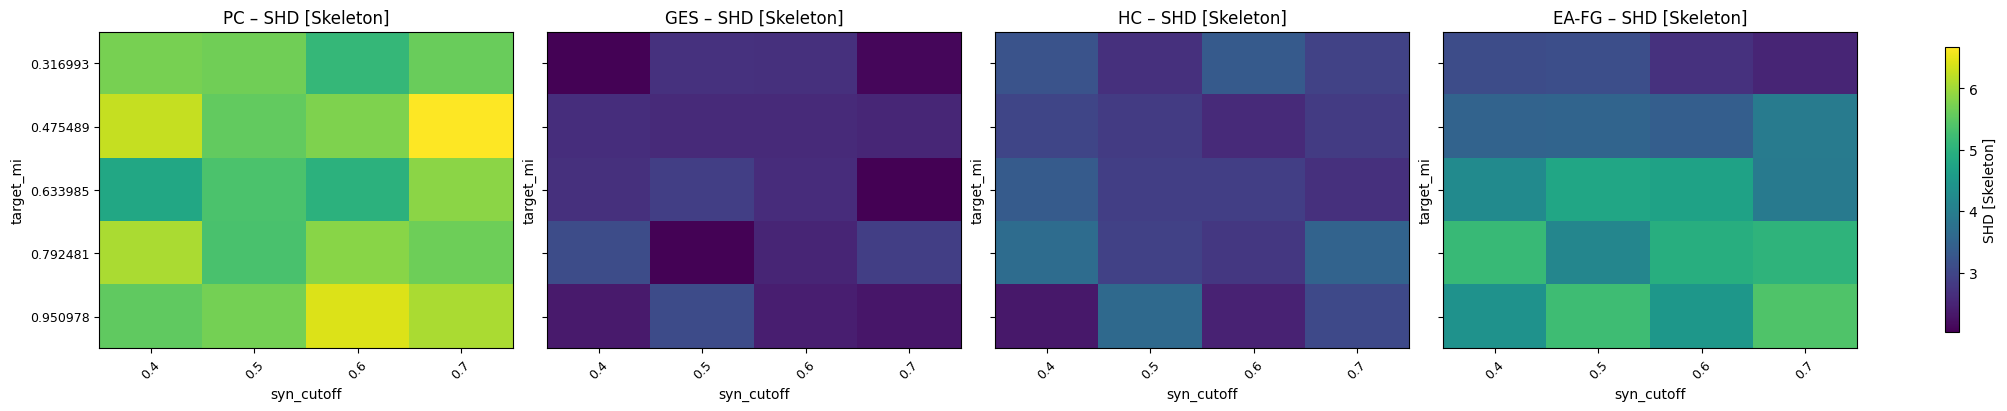

In [8]:
metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/global/benchmark_{metric}.png", dpi=600, bbox_inches='tight')

### Colliders 

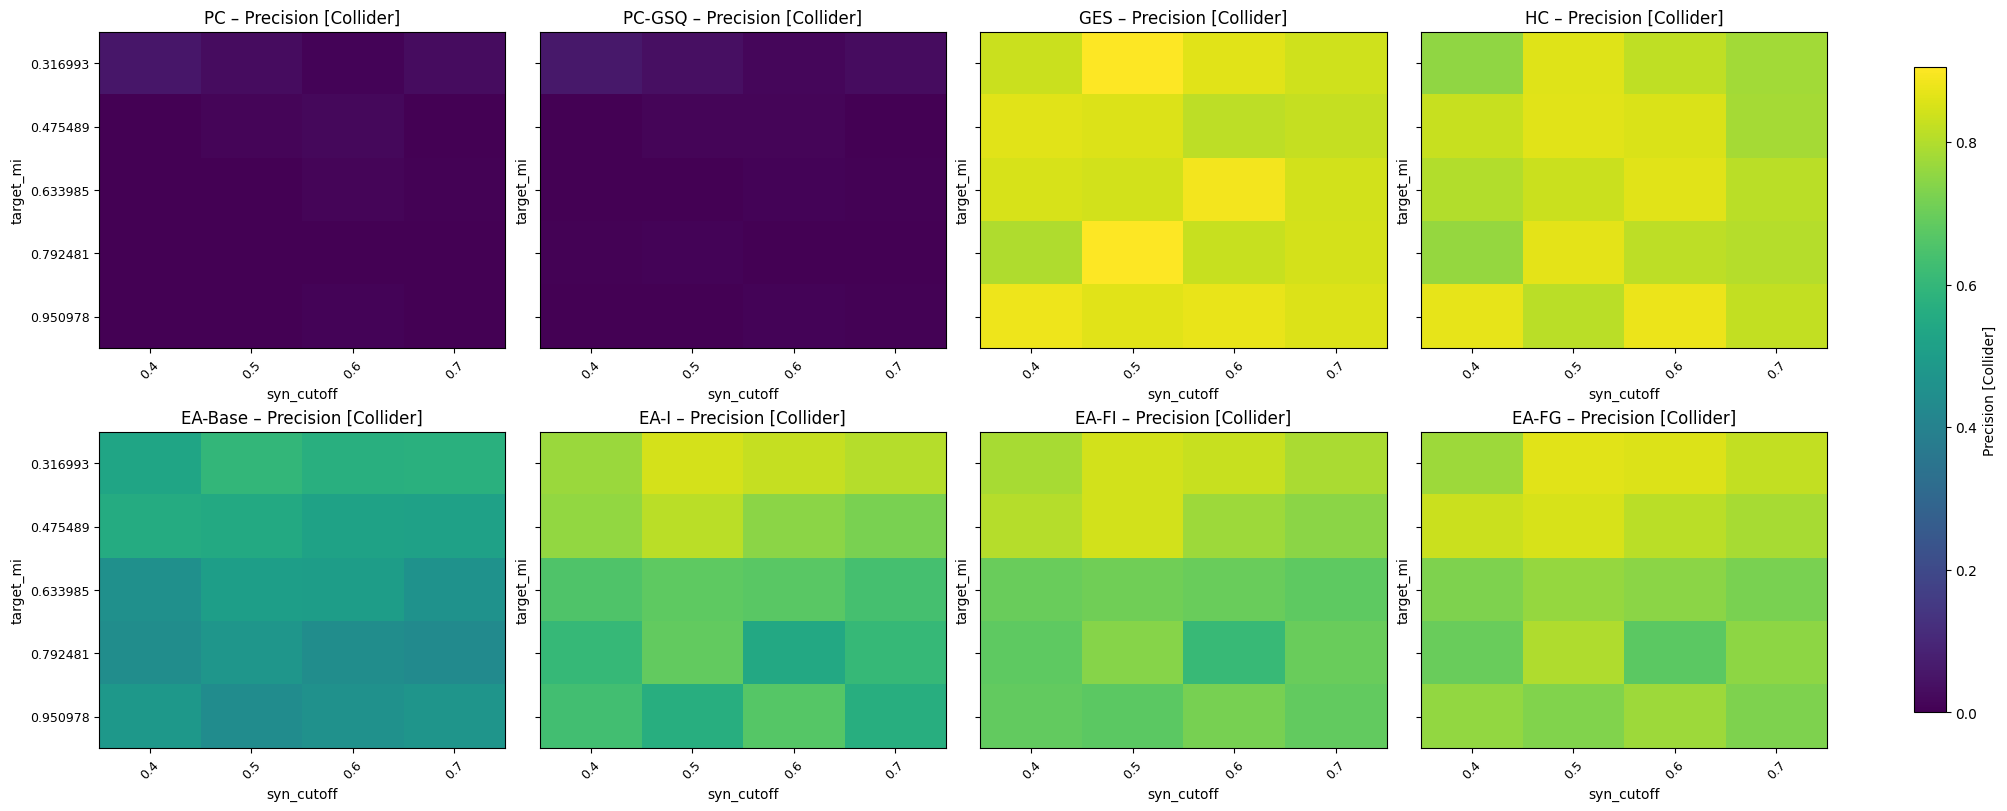

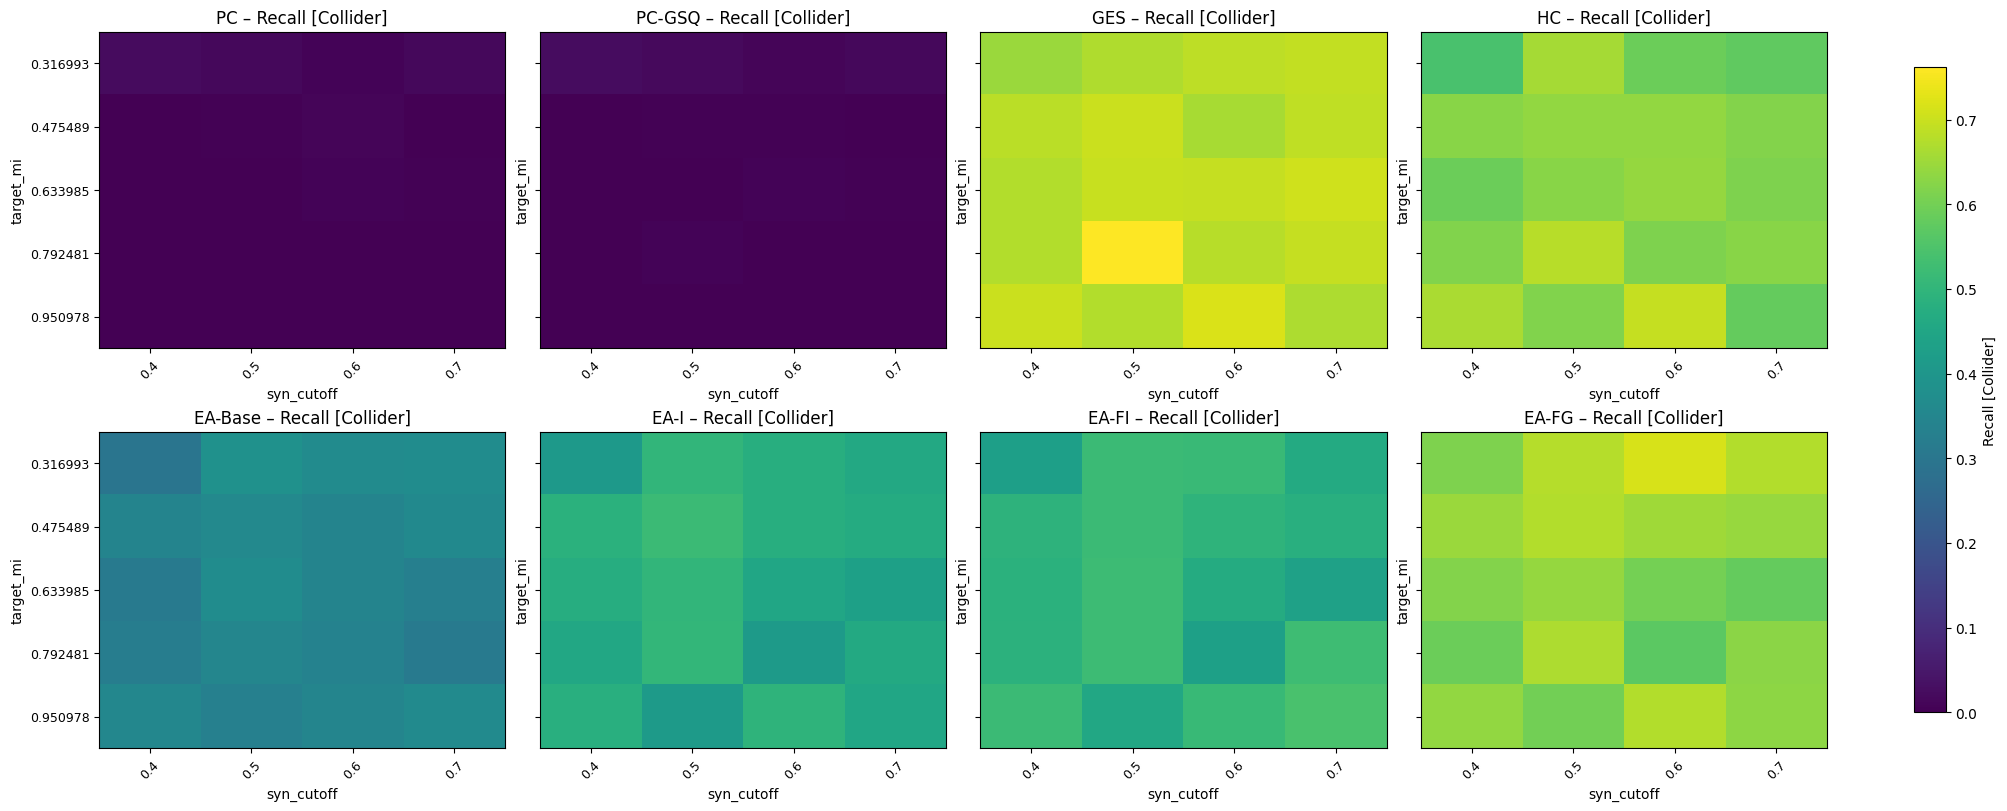

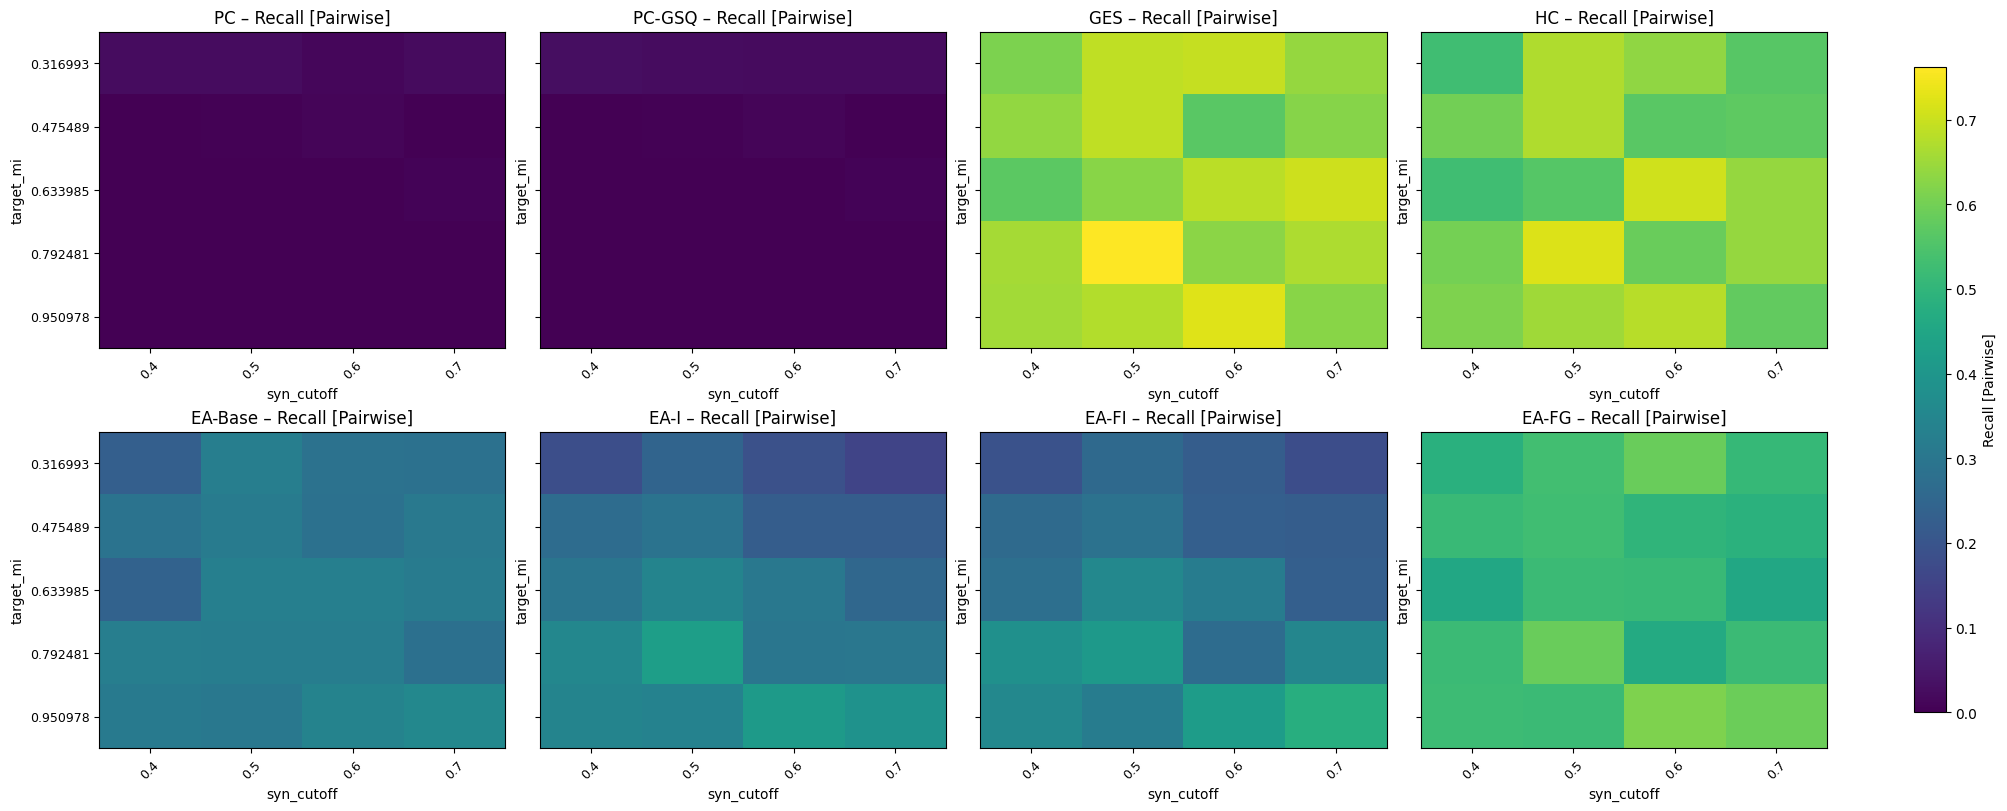

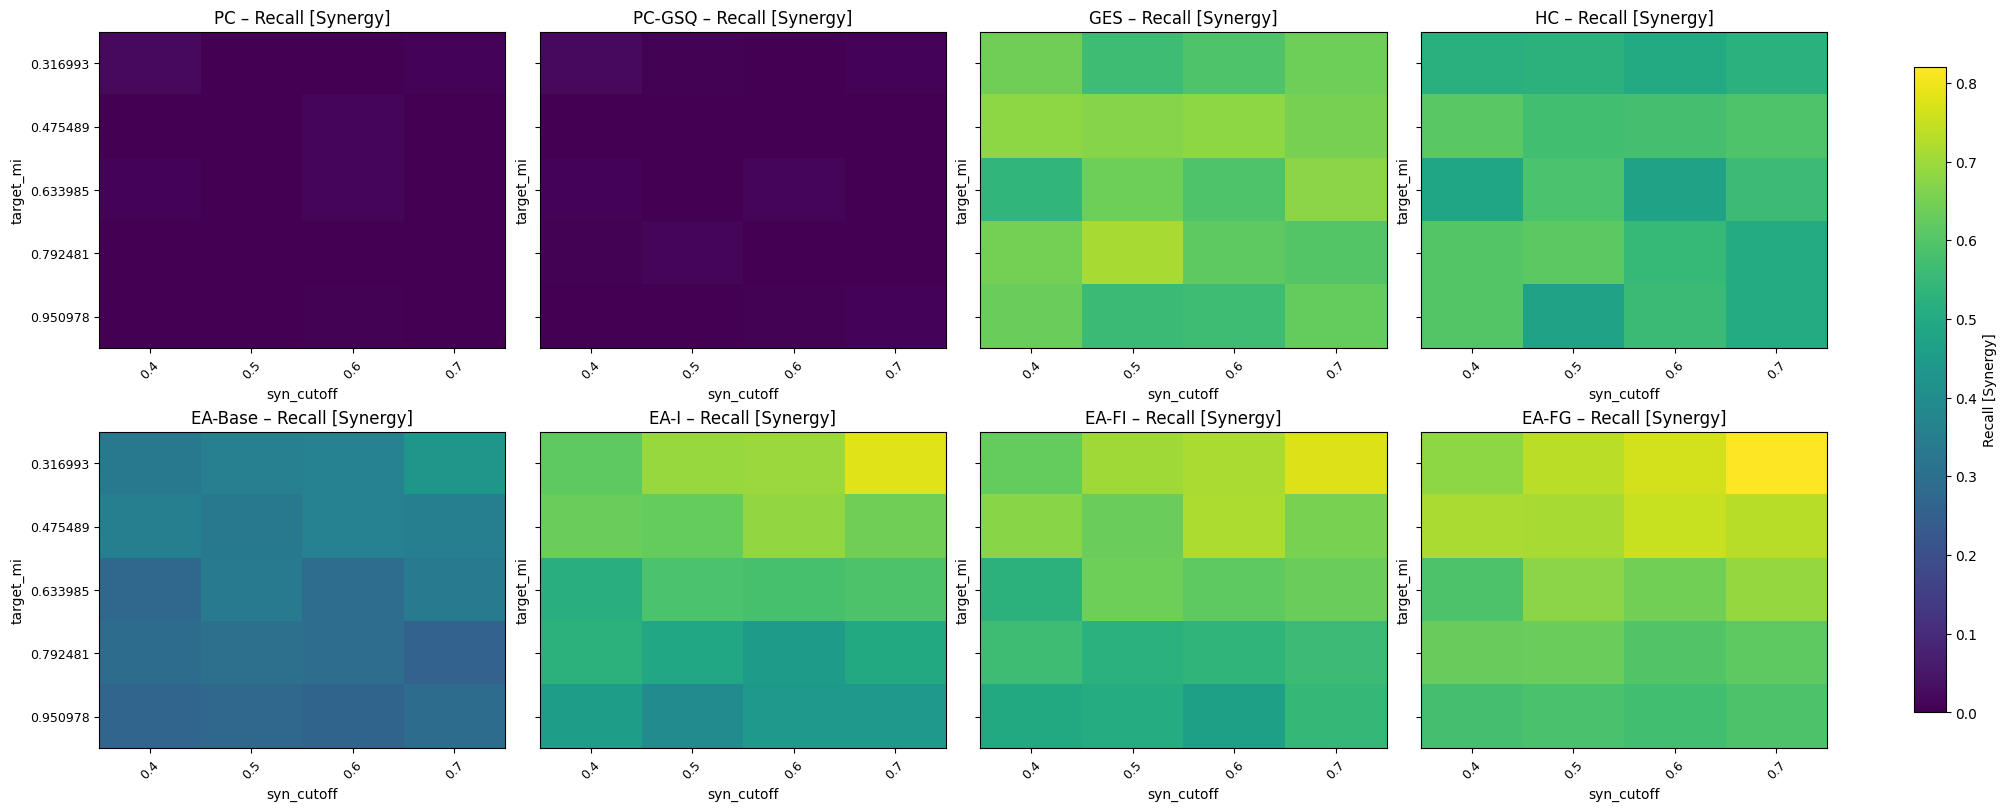

In [ ]:
metrics = ["Precision [Collider]", "Recall [Collider]", "Recall [Pairwise]", "Recall [Synergy]"] 
for metric in metrics:
    fig, axes = plot_final_heatmap(
        results_by_label,
        # mapping=mapping,
        subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=None,
        y_col=y_col,
    )

    plt.savefig(f"plots/{subset}/collider/benchmark_{metric}.png", dpi=600, bbox_inches='tight')


In [ ]:
# # Pick the metric you want (change this string)
# metric = "Recall (Synergy)"   # or "F1 (Collider)", "SHD", "Recall (Synergy)"

# # for metric in ["SHD", "F1 (Collider)", "Recall (Synergy)", "Recall (Collider)"]:

# for filter_val in [0.5, 0.7, 0.9]:
#     fig, axes = plot_final_heatmap(
#         results_by_label,
#         # mapping=mapping,
#         subset_metrics=[metric, x_col, y_col, filter_col],
#         plot_metric=metric,
#         x_col=x_col,
#         aggfunc="median",
#         filter=(filter_col, filter_val),
#         y_col=y_col,
#     )


#     plt.savefig(f"plots/RQ1_JPMFPairs{filter_val}_{metric}.png", dpi=800)


In [ ]:
# # Pick the metric you want (change this string)
# metric = "Recall (Collider)"   # or "F1 (Collider)", "SHD", "Recall (Synergy)"
# # x_col="p_noise"
# # y_col="n_xor"
# # Close prior figures to avoid stacking / memory leaks
# # plt.close("all")

# # for metric in ["SHD", "F1 (Collider)", "Recall (Synergy)", "Recall (Collider)"]:
# for filter_val in [0.5, 0.7, 0.9]:
#     fig, axes = plot_final_heatmap(
#         results_by_label,
#         # mapping=mapping,
#         subset_metrics=[metric, x_col, y_col, filter_col],
#         plot_metric=metric,
#         x_col=x_col,
#         filter=(filter_col, filter_val),
#         y_col=y_col,
#         aggfunc="median",
#     )


#     plt.savefig(f"plots/RQ1_JPMFPairs{filter_val}_{metric}.png", dpi=800)


In [42]:
long_df.to_csv(f"results/{subset}_long_metrics.csv", index=False)

In [40]:
import pandas as pd

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

long_df = build_long_metrics(results_by_label)


### Metrics

In [ ]:
# ea_long = long_df[long_df["Algorithm"].str.contains("EA")]

In [ ]:
# subset_df = ea_long[
#     (ea_long["pair_probs"] == 0.5) & 
#     (ea_long["syn_cutoff"] == 0.7)
# ]

In [ ]:
# min(subset_df["Recall (Synergy)"])

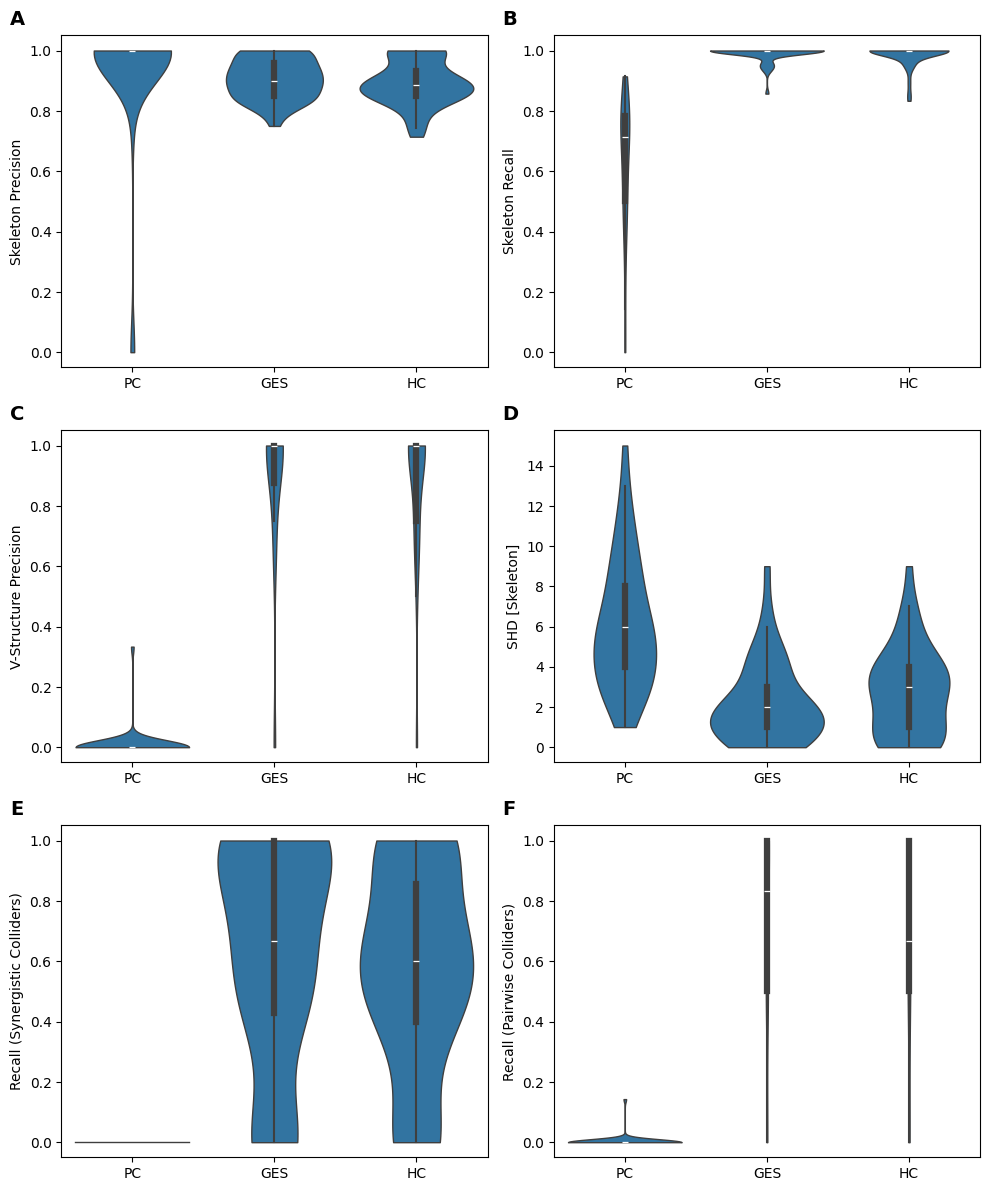

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
subset = "jpmf_grid"

def violin_grid_2x2(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


metrics = {
    "A": ("Precision [Skeleton]", "Skeleton Precision"),
    "B": ("Recall [Skeleton]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall [Synergy]", "Recall (Synergistic Colliders)"),
    "F": ("Recall [Pairwise]", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC"] #  , "EA Informed"] 

# Example slice (optional):
filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.7}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/jpmf_data//RQ1_Violin_{subset}_pairs{filter_dict['pair_probs']}_syn{filter_dict['syn_cutoff']}.png",
    dpi=800,
)


## 1.3: Tradeoffs EA+HC

In [ ]:
import pickle

subset = 'binary_grid'
subset = 'jpmf_grid'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_hc_inf = pickle.load(f)

    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA-I": results_ea_ies,
        "EA-FG": results_ea_fg,
        # "HC Informed": results_hc_inf,
        # "EA Uninformed": results_ea_ues,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)

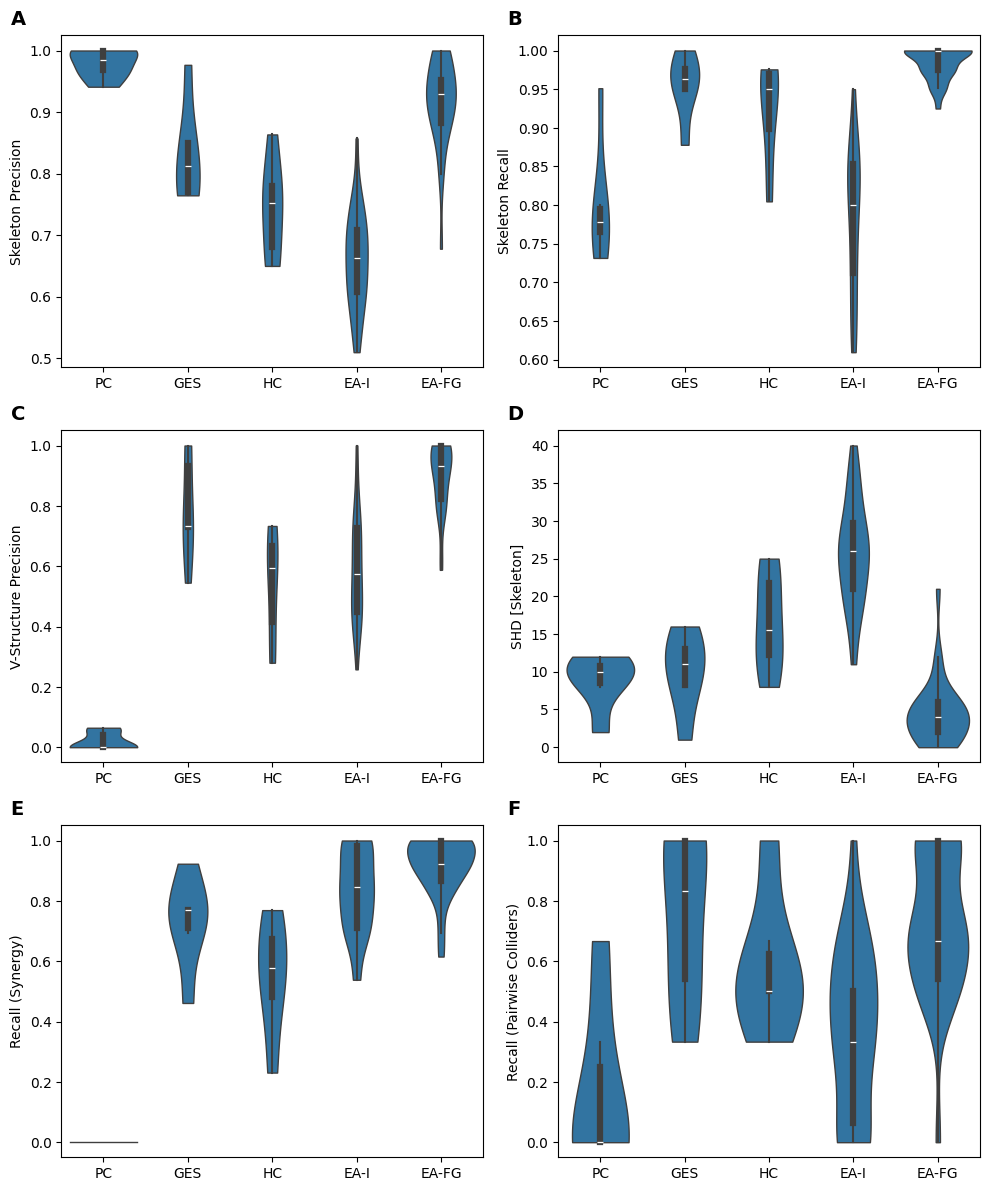

In [ ]:
long_df = build_long_metrics(results_by_label)

metrics = {
    "A": ("Precision [Adjacency]", "Skeleton Precision"),
    "B": ("Recall [Adjacency]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall (Synergy)", "Recall (Synergy)"),
    "F": ("Recall (Pairwise)", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC", "EA-I", "EA-FG"]  # or whatever you want

# Example slice (optional):
filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.7}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/RQ2_Violin_{subset}_pairs{filter_dict['pair_probs']}_syn{filter_dict['syn_cutoff']}.png",
    dpi=800,
)


In [ ]:
### Metrics and Algorithms
np.unique(long_df["Algorithm"])

array(['EA-FG', 'EA-I', 'GES', 'HC', 'PC'], dtype=object)

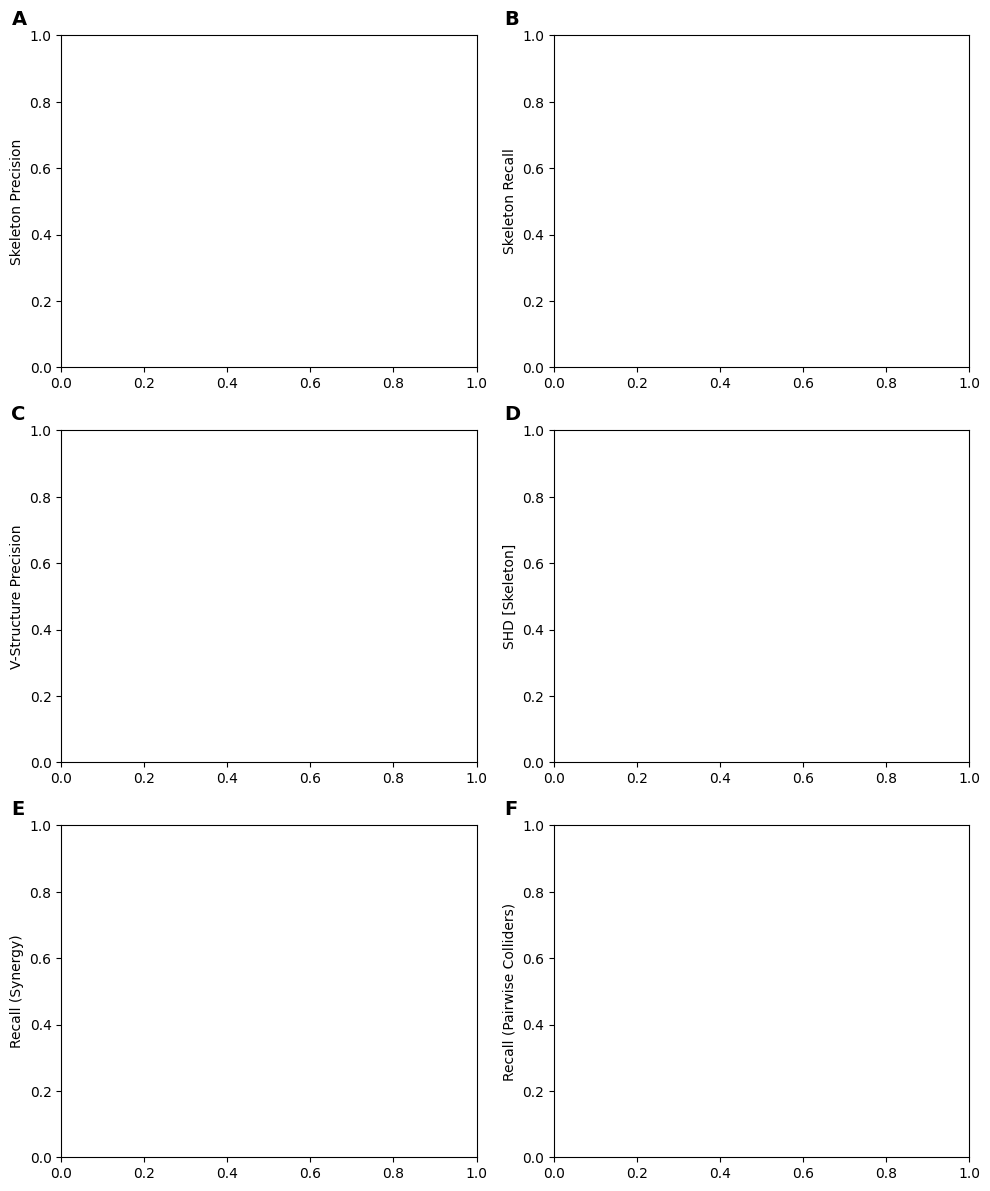

In [ ]:

metrics = {
    "A": ("Precision [Adjacency]", "Skeleton Precision"),
    "B": ("Recall [Adjacency]", "Skeleton Recall"),
    "C": ("Precision (Collider)", "V-Structure Precision"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "E": ("Recall (Synergy)", "Recall (Synergy)"),
    "F": ("Recall (Pairwise)", "Recall (Pairwise Colliders)"),
}

alg_order = ["PC", "GES", "HC", "EA-I", "EA-FG"]  # or whatever you want

# Example slice (optional):
filter_dict = {"pair_probs": 0.3}
# filter_dict = None

fig, axes = violin_grid_2x2(
    long_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(10, 12),
)

plt.savefig(
    f"plots/RQ2_Violin_{subset}_pairs{filter_dict['pair_probs']}.png",
    dpi=800,
)
